In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [80]:
df = pd.read_csv("3-customersatisfaction.csv")

In [81]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [82]:
df.drop("Unnamed: 0",axis = 1,inplace=True)

In [83]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [84]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


Text(0, 0.5, 'Incentive')

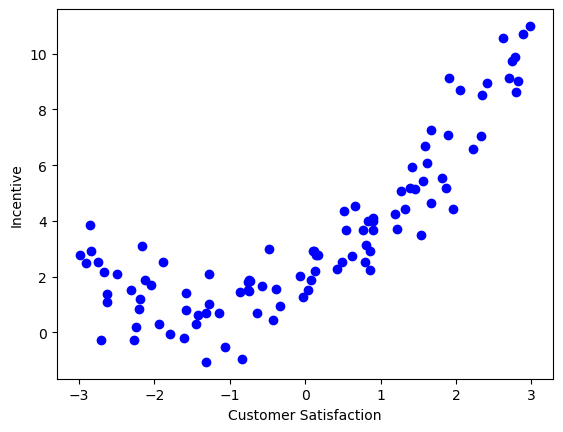

In [85]:
plt.scatter(df["Customer Satisfaction"],df["Incentive"],color="b")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")

In [86]:
#dependent n independent features
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [87]:
# train - test split

In [88]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 15)

In [89]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [90]:
regression = LinearRegression()

In [91]:
# scaler

In [92]:
scaler = StandardScaler()

In [93]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
regression = LinearRegression()

In [95]:
regression.fit(X_train,y_train)

LinearRegression()

In [96]:
y_pred = regression.predict(X_test)

In [97]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [98]:
score = r2_score(y_test,y_pred)
print(score)

0.2705652535622246


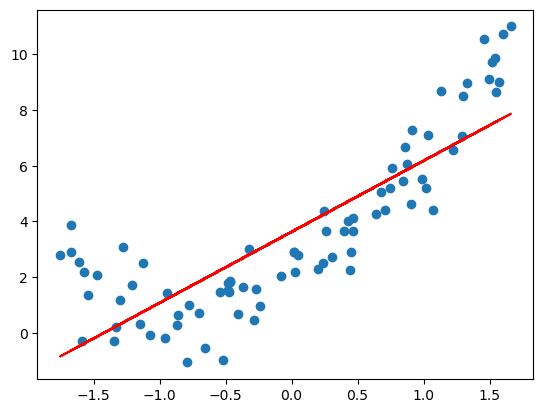

In [99]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color = "r")
plt.show()

In [115]:
poly = PolynomialFeatures(degree=2,include_bias=True)

In [116]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [117]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [118]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

ValueError: X has 3 features, but LinearRegression is expecting 1 features as input.

In [119]:
# print("Modelin beklediği özellik sayısı:", regression.n_features_in_)
# print("X_train shape:", getattr(X_train, "shape", None))
# print("X_train_poly shape:", getattr(X_train_poly, "shape", None))
# print("X_test_poly shape:", getattr(X_test_poly, "shape", None))


In [121]:
#new data


In [122]:
new_df = pd.read_csv("3-newdatas.csv")